## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

##### 3.1.1 Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра.
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [ ]:
!pip install scipy
!pip install scikit-learn

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [ ]:
# Клонируем свой форк репозитория с GitHub
!git clone https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse.git

Cloning into '2025-Selyutin-TimeSeriesCourse'...
remote: Enumerating objects: 257, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 257 (delta 7), reused 0 (delta 0), pack-reused 212 (from 2)
Receiving objects: 100% (257/257), 232.69 MiB | 22.43 MiB/s, done.
Resolving deltas: 100% (17/17), done.
Updating files: 100% (195/195), done.


In [ ]:
%cd 2025-Selyutin-TimeSeriesCourse/practice/"03 Discords"

/content/2025-Selyutin-TimeSeriesCourse/practice/03 Discords


In [ ]:
!ls

'03 Discords.ipynb'   datasets	 modules   pics


In [ ]:
#fixme: Путь
dataset_dir_path = Path('datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

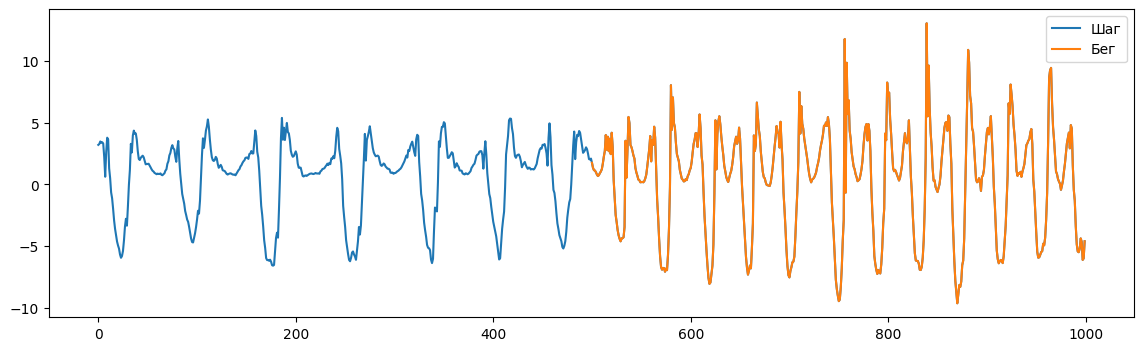

In [ ]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [ ]:
result={}
times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [ ]:
from modules.saxpy.discord import find_discords_brute_force
start = time()
discords_brute_force= np.stack(find_discords_brute_force(data[:], 50, 5))
end = time()

Время работы замерил в пункте 3.1.4

##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [ ]:
# INSERT YOUR CODE
import time
from modules.saxpy.hotsax import find_discords_hotsax

# Размер подокна
n_sub = 50
# Количество диссонансов
top_n = 5

In [ ]:
start = time.time()
discords_hotsax = np.stack(find_discords_hotsax(data[:], n_sub, top_n))
end = time.time()

In [ ]:
print(f"Время работы HotSAX: {end - start:.6f} секунд")
print("Топ 5 диссонансов:")
print(discords_hotsax)

Время работы HotSAX: 2.860556 секунд
Топ 5 диссонансов:
[[477.           5.88100934]
 [412.           5.32704317]
 [195.           3.39426635]
 [577.           3.35554403]
 [278.           3.10959389]]


Первое число — индекс начала найденного диссонанса (аномального участка) во временном ряду.

Второе число — расстояние до ближайшего похожего подокна (мера «аномальности»); чем оно больше, тем участок сильнее отличается от остальной части данных.

##### 3.1.4 Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

Пример графика:

![first_graf](https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse/blob/main/practice/03%20Discords/pics/fig_ex_1.png?raw=1)

In [ ]:
# INSERT YOUR CODE
import numpy as np
import matplotlib.pyplot as plt
from time import time
from modules.saxpy.discord import find_discords_brute_force
from modules.saxpy.hotsax import find_discords_hotsax


In [ ]:
n_sub = 50
top_n = 5

In [ ]:
# BruteForce
start = time()
discords_brute_force = np.stack(find_discords_brute_force(data[:], n_sub, top_n))
time_brute = time() - start

In [ ]:
# HotSAX
start = time()
discords_hotsax = np.stack(find_discords_hotsax(data[:], n_sub, top_n))
time_hotsax = time() - start

In [ ]:
print(f"Brute Force: {time_brute:.4f} сек\nHotSAX: {time_hotsax:.4f} сек\n")

Brute Force: 147.9415 сек
HotSAX: 2.7819 сек



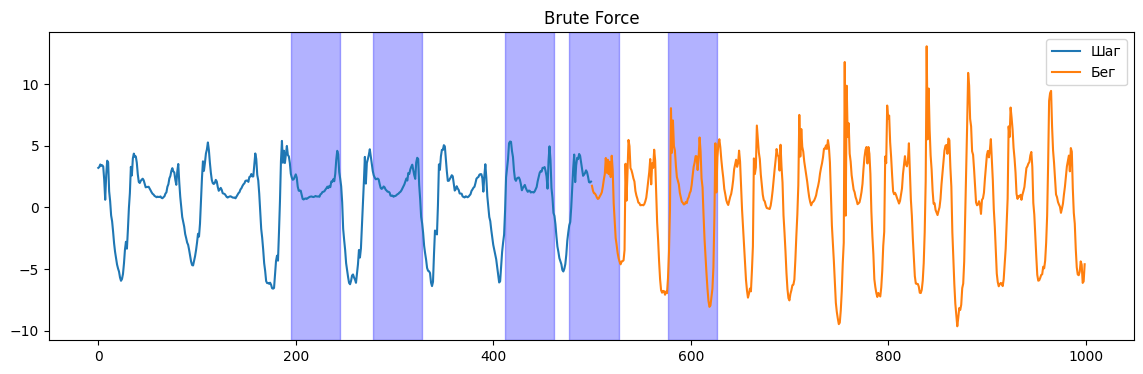

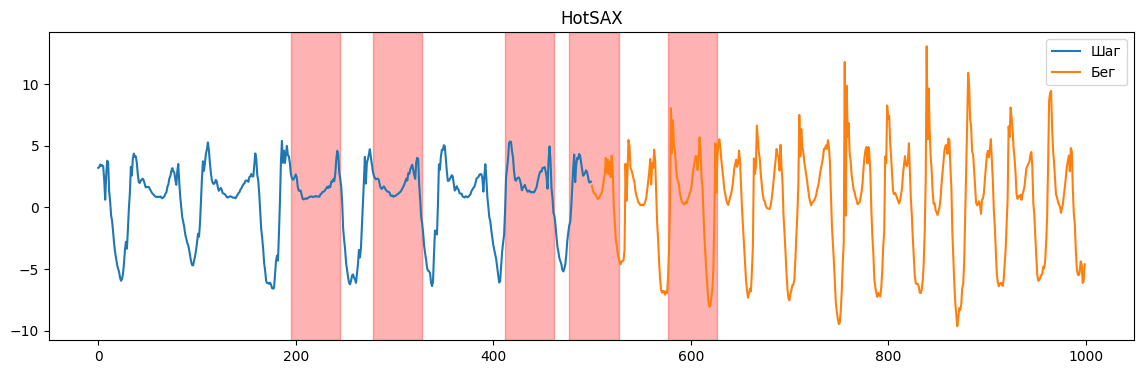

In [ ]:
mid = data.shape[0] // 2  # граница между шагом и бегом

# Brute Force
fig, ax = plt.subplots(figsize=(14,4))

ax.plot(data[:mid], label='Шаг')
ax.plot(np.arange(mid, data.shape[0]), data[mid:], label='Бег')

# Диссонансы Brute Force
for idx, dist in discords_brute_force:
    ax.axvspan(int(idx), int(idx) + n_sub, color='blue', alpha=0.3)

ax.set_title('Brute Force')
ax.legend()
plt.show()

# HotSAX
fig, ax = plt.subplots(figsize=(14,4))

ax.plot(data[:mid], label='Шаг')
ax.plot(np.arange(mid, data.shape[0]), data[mid:], label='Бег')

# Диссонансы HotSAX
for idx, dist in discords_hotsax:
    ax.axvspan(int(idx), int(idx) + n_sub, color='red', alpha=0.3)

ax.set_title('HotSAX')
ax.legend()
plt.show()

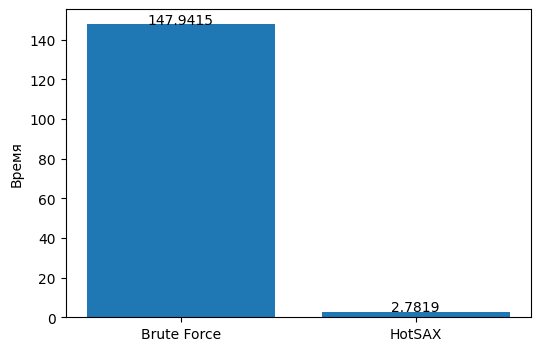

In [ ]:
plt.figure(figsize=(6,4))
algorithms = ['Brute Force', 'HotSAX']
times = [time_brute, time_hotsax]

plt.bar(algorithms, times)
plt.ylabel('Время')
for i, v in enumerate(times):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.show()

In [ ]:
from matplotlib.patches import Rectangle

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами.

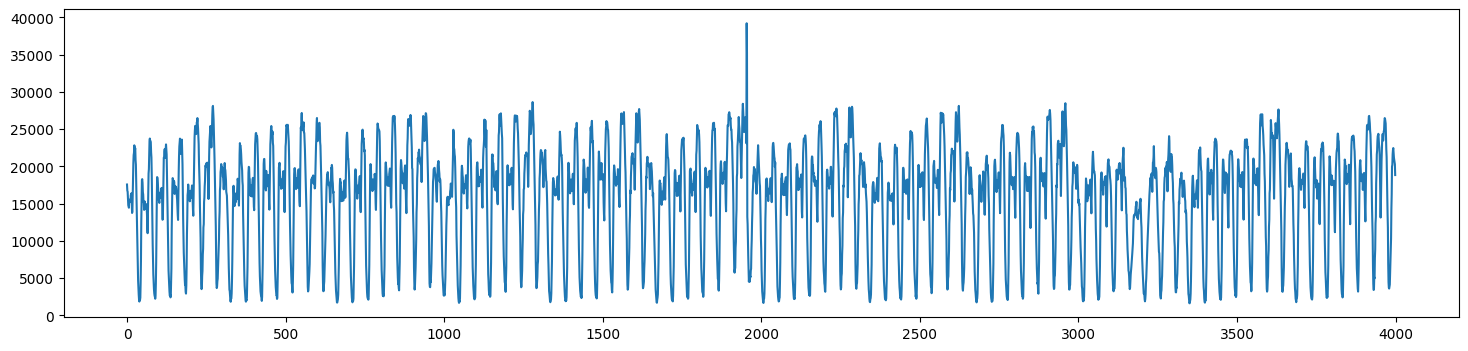

In [ ]:
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

In [ ]:
# INSERT YOUR CODE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from modules.saxpy.discord import find_discords_brute_force
from modules.saxpy.hotsax import find_discords_hotsax

nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv', index_col=0).values[4000:8000,0].astype(np.float64)
data_nyc = nyc_taxi

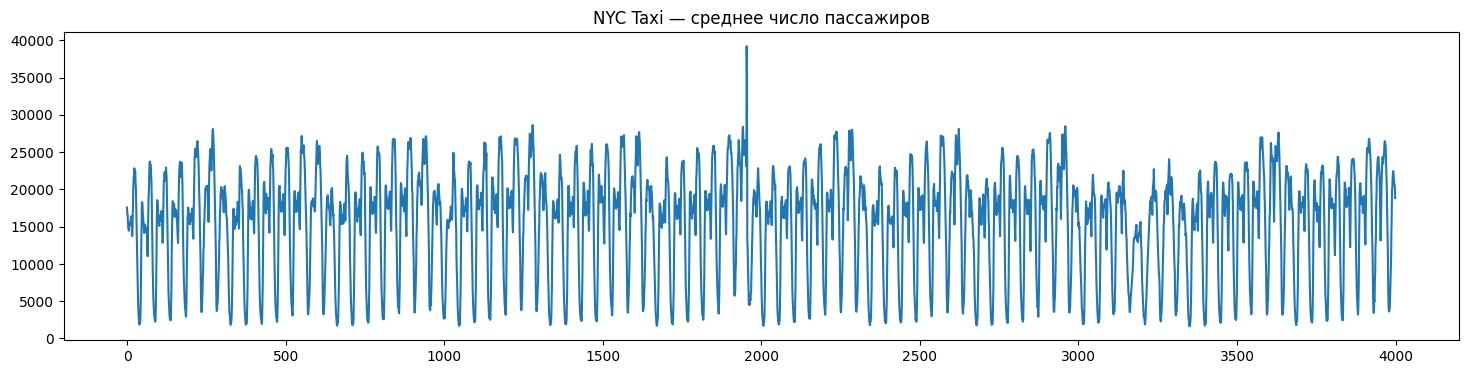

In [ ]:
fig = plt.figure(figsize=(18, 4))
plt.plot(data_nyc)
plt.title('NYC Taxi — среднее число пассажиров')
plt.show()

In [ ]:
n_sub = 5
top_n = 5

In [ ]:
# Brute Force
start = time()
discords_brute = np.stack(find_discords_brute_force(data_nyc, n_sub, top_n))
time_brute = time() - start
print(f"Brute Force: {time_brute:.4f} сек")

Brute Force: 3314.9621 сек


In [ ]:
# HotSAX
start = time()
discords_hotsax = np.stack(find_discords_hotsax(data_nyc, n_sub, top_n))
time_hotsax = time() - start
print(f"HotSAX: {time_hotsax:.4f} сек")

HotSAX: 4.9645 сек


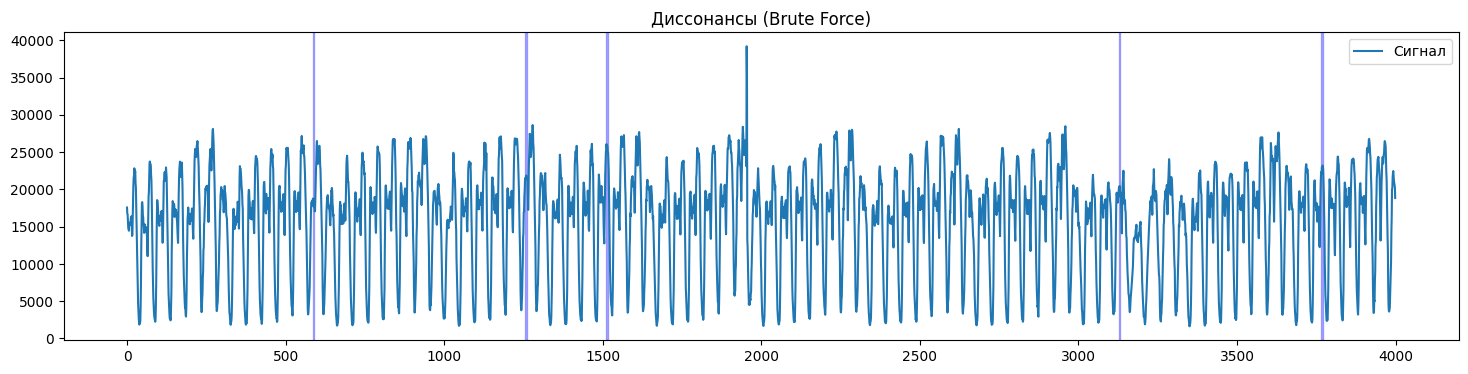

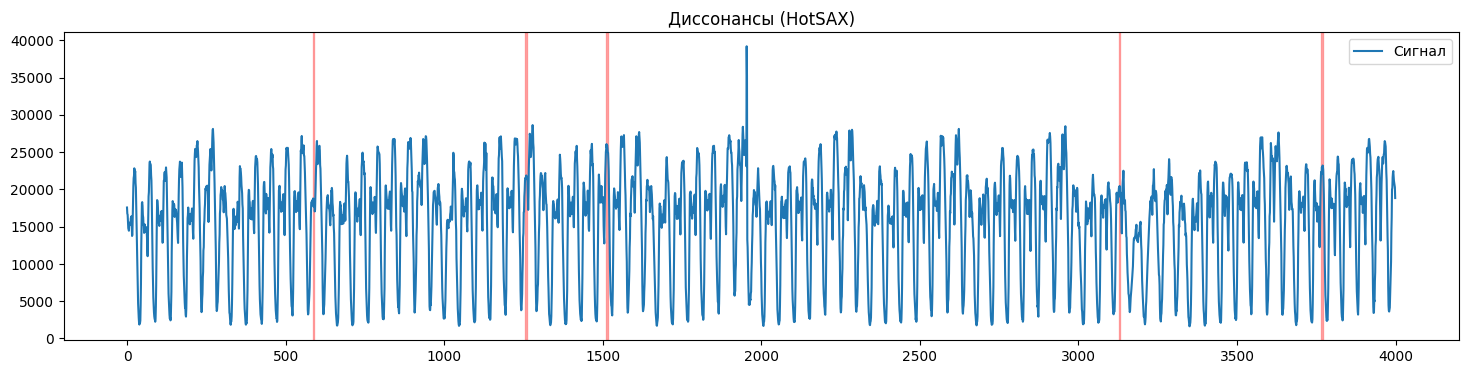

In [ ]:
# Визуализация диссонансов
# Brute Force
fig, ax = plt.subplots(figsize=(18,4))
ax.plot(data_nyc, label='Сигнал')
for idx, dist in discords_brute:
    ax.axvspan(int(idx), int(idx)+n_sub, color='blue', alpha=0.3)
ax.set_title('Диссонансы (Brute Force)')
ax.legend()
plt.show()

# HotSAX
fig, ax = plt.subplots(figsize=(18,4))
ax.plot(data_nyc, label='Сигнал')
for idx, dist in discords_hotsax:
    ax.axvspan(int(idx), int(idx)+n_sub, color='red', alpha=0.3)
ax.set_title('Диссонансы (HotSAX)')
ax.legend()
plt.show()

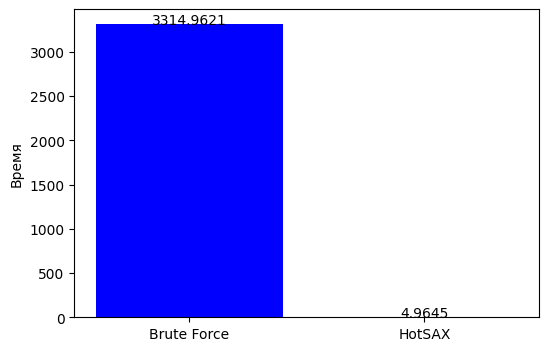

In [ ]:
# Сравнение времени работы
plt.figure(figsize=(6,4))
algorithms = ['Brute Force', 'HotSAX']
times = [time_brute, time_hotsax]
plt.bar(algorithms, times, color=['blue', 'red'])
plt.ylabel('Время')
for i, v in enumerate(times):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.show()

Из-за большого объёма данных выполнение алгоритма Brute Force с исходными параметрами занимало слишком много времени. Для практической работы было решено уменьшить длину подокна до n_sub = 5
Это позволило существенно сократить время выполнения и получить результаты за приемлемый промежуток времени

Алгоритм Brute Force даёт точные результаты, но его время работы растёт квадратично с длиной ряда и размером подокна, из-за чего на больших данных выполнение может занимать часы (в нашем случае Brute Force: 3314.96 сек)

Алгоритм HotSAX работает значительно быстрее - за секунды, при этом находит аналогичные диссонансы. Для практического анализа больших временных рядов использование HotSAX является предпочтительным, поскольку позволяет быстро выявлять аномальные участки без потери качества обнаружения.

# INSERT YOUR CODE

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [1]:
!pip install stumpy==1.11.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.2/136.2 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: stumpy
    Found existing installation: stumpy 1.13.0
    Uninstalling stumpy-1.13.0:
      Successfully uninstalled stumpy-1.13.0


In [2]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump


In [32]:
# Клонируем свой форк репозитория с GitHub
!git clone https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse.git

Cloning into '2025-Selyutin-TimeSeriesCourse'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 262 (delta 9), reused 2 (delta 2), pack-reused 213 (from 1)
Receiving objects: 100% (262/262), 233.43 MiB | 22.20 MiB/s, done.
Resolving deltas: 100% (19/19), done.
Updating files: 100% (196/196), done.


In [33]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [34]:
%cd 2025-Selyutin-TimeSeriesCourse/practice/"03 Discords"

/content/2025-Selyutin-TimeSeriesCourse/practice/03 Discords/2025-Selyutin-TimeSeriesCourse/practice/03 Discords


In [35]:
!ls

'03 Discords.ipynb'   03_Discords_part1.ipynb   datasets   modules   pics


In [36]:
#fixme: Путь
dataset_dir_path = Path('datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога.

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [42]:
from modules.drag import find_candidates, DRAG


Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [43]:
data = walk_run

In [44]:
!pwd

/content/2025-Selyutin-TimeSeriesCourse/practice/03 Discords/2025-Selyutin-TimeSeriesCourse/practice/03 Discords


Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [52]:
# AttributeError: `np.NINF` was removed in the NumPy 2.0 release. Use `-np.inf` instead.
!sed -i 's/np.NINF/-np.inf/g' "modules/drag.py"
from importlib import reload
import modules.drag
reload(modules.drag)
from modules.drag import find_candidates, DRAG





In [53]:
m = 50
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат.

In [54]:
m = 50
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse/blob/main/practice/03%20Discords/pics/fig_ex_2.png?raw=1)

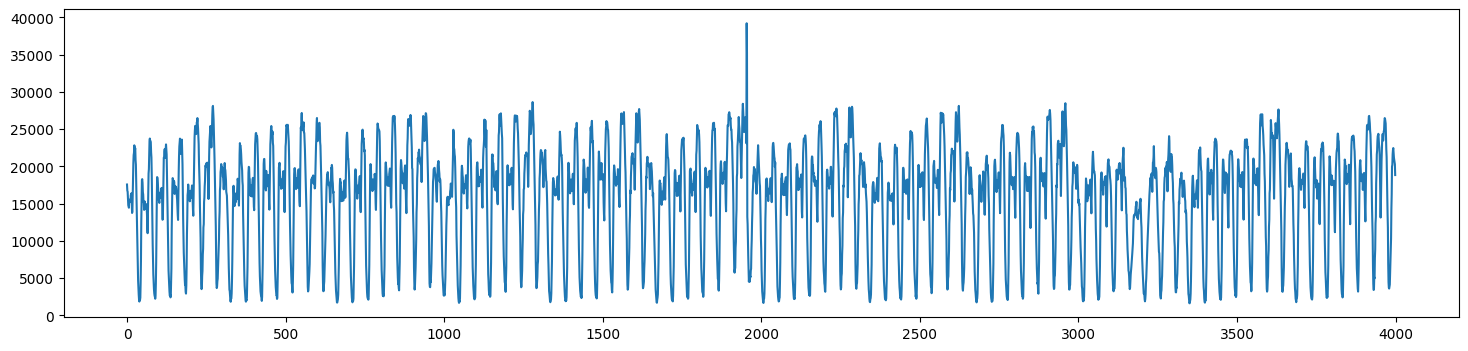

In [55]:
# INSERT YOUR CODE
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

In [56]:
m = 50
r = 1
# DRAG

idxs, dist, nn = DRAG(nyc_taxi, m, r)
print(f"Количество найденных диссонансов: {len(idxs)}")

Количество найденных диссонансов: 42


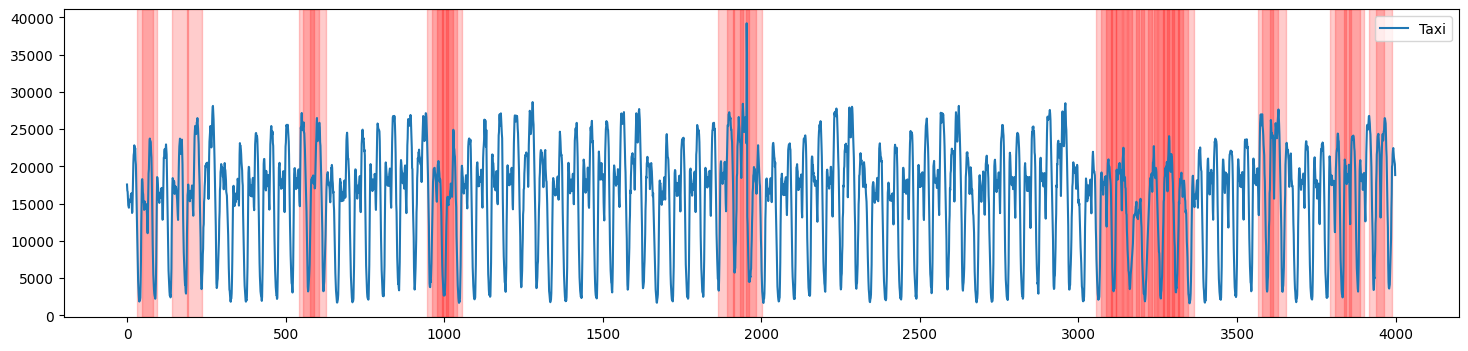

In [63]:
fig, ax = plt.subplots(figsize=(18,4))
ax.plot(nyc_taxi, label="Taxi")

for idx in idxs:
    ax.axvspan(idx, idx + m, color='red', alpha=0.2)
ax.legend()
plt.show()

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [64]:
#выбирем более реальное значение для порога
r = 3

In [65]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1,
#элемент массива является истинным,
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [66]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности.
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

In [69]:
m = 50
r = 3
T, M_T, Σ_T = core.preprocess(nyc_taxi, m)

# Находим потенциальных кандидатов
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
cand_index = np.flatnonzero(is_cands)

print(f"{len(cand_index)} кандидатов, {len(cand_index)/len(nyc_taxi)*100:.2f}% от ряда")

119 кандидатов, 2.97% от ряда


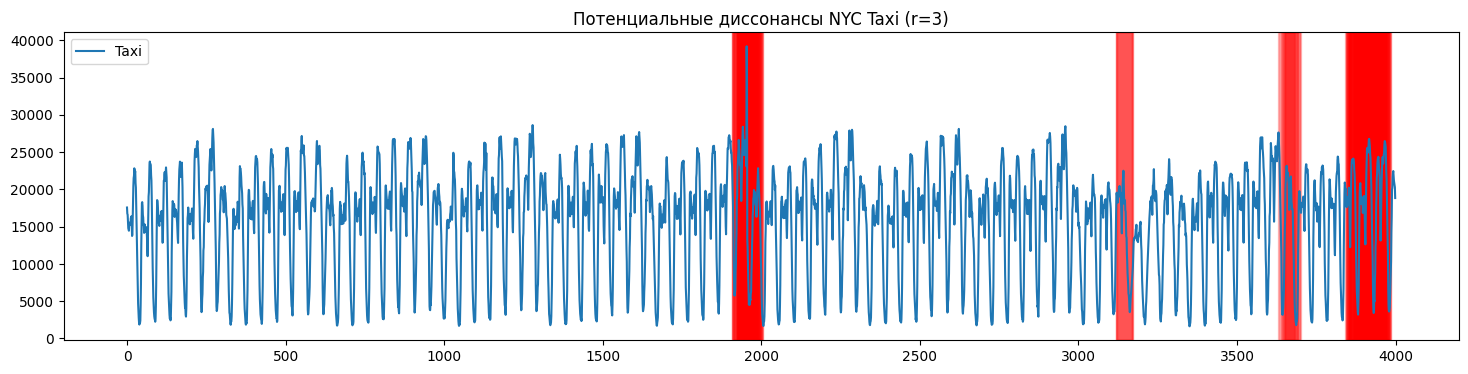

In [72]:
fig, ax = plt.subplots(figsize=(18,4))
ax.plot(nyc_taxi, label="Taxi")

for idx in cand_index:
    ax.axvspan(idx, idx + m, color='red', alpha=0.2)

ax.set_title(f"Потенциальные диссонансы NYC Taxi (r={r})")
ax.legend()
plt.show()

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [ ]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [ ]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

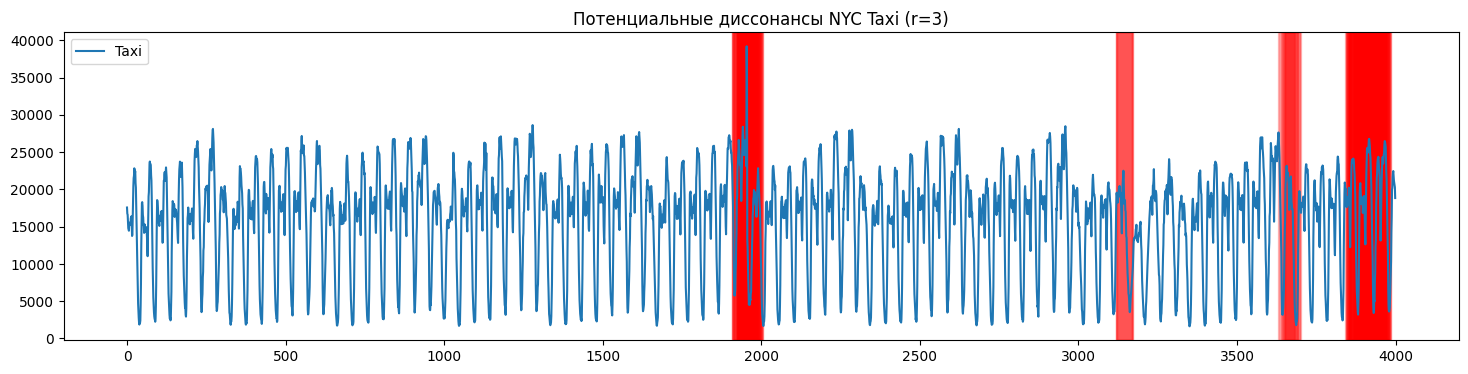

In [73]:
# INSERT YOUR CODE
# В пункте выше производилась очистка кандидатов: 119 кандидатов, 2.97% от ряда
fig, ax = plt.subplots(figsize=(18,4))
ax.plot(nyc_taxi, label="Taxi")

for idx in cand_index:
    ax.axvspan(idx, idx + m, color='red', alpha=0.2)

ax.set_title(f"Потенциальные диссонансы NYC Taxi (r={r})")
ax.legend()
plt.show()

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [75]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

1.0999999999999999

Сформируйте график найденных диссонансов

In [79]:
# INSERT YOUR CODE
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)

# Доля диссонансов
percent_discords = len(discords_idx)/len(nyc_taxi)*100
print(f"Количество диссонансов: {len(discords_idx)}")
print(f"Доля ряда: {percent_discords:.2f}%")

Количество диссонансов: 11
Доля ряда: 0.27%


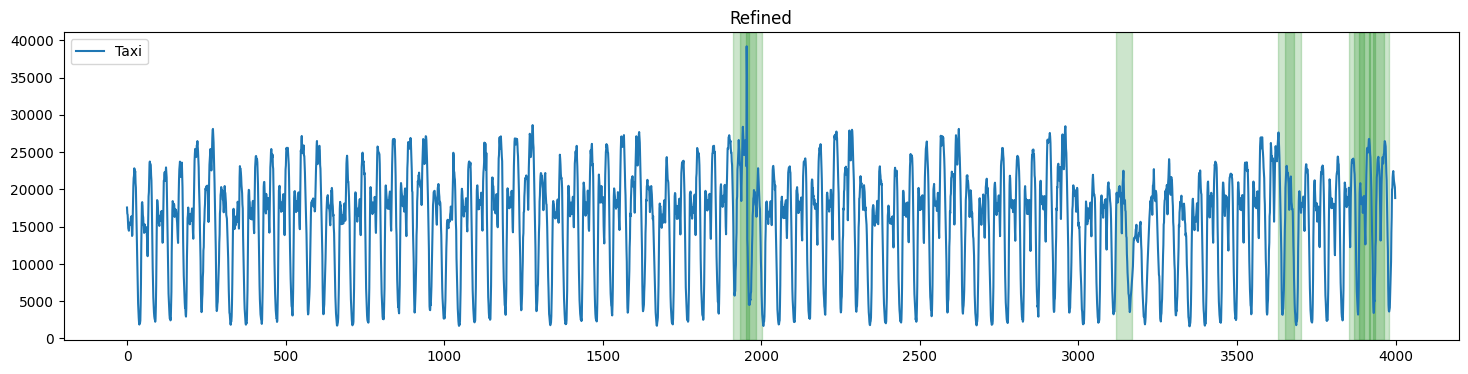

In [83]:
fig, ax = plt.subplots(figsize=(18,4))
ax.plot(nyc_taxi, label="Taxi")

for idx in discords_idx:
    ax.axvspan(idx, idx + m, color='green', alpha=0.2)

ax.set_title("Refined")
ax.legend()
plt.show()

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY.
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


In [87]:
# INSERT YOUR CODE
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)

In [91]:
def run_drag_visual(data, m, r):
    T, M_T, Σ_T = core.preprocess(data, m)

    # Находим кандидатов
    is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)

    # Отбор реальных диссонансов
    discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)

    # Визуализация результатов разных комбинаций
    fig, ax = plt.subplots(figsize=(18,4))
    ax.plot(data, label="Taxi")
    for idx in discords_idx:
        ax.axvspan(idx, idx + m, color='green', alpha=0.2)
    ax.set_title(f"DRAG: m={m}, r={r} - найдено {len(discords_idx)} диссонансов")
    ax.legend()
    plt.show()

    return len(discords_idx)

\Параметры: m=20, r=1


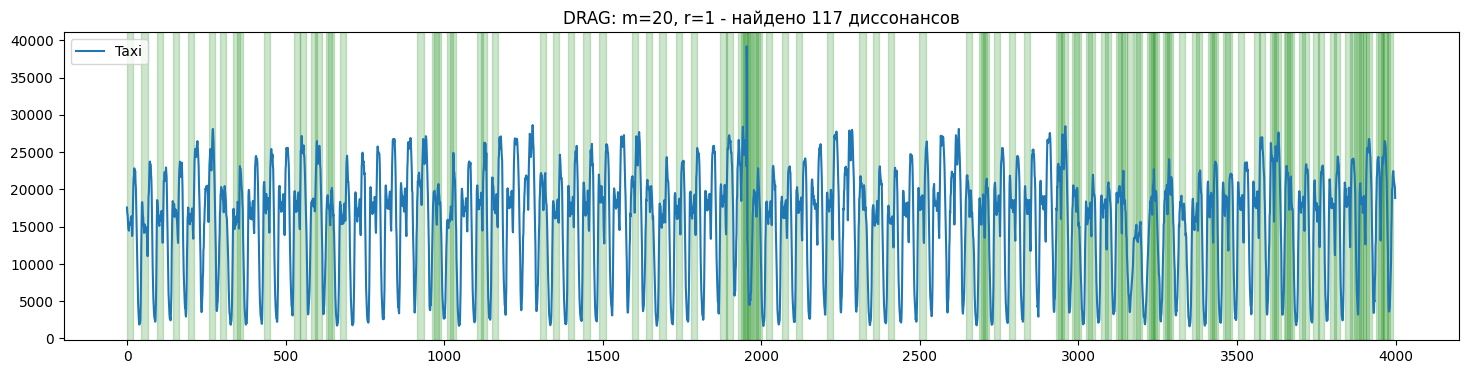

\Параметры: m=20, r=2


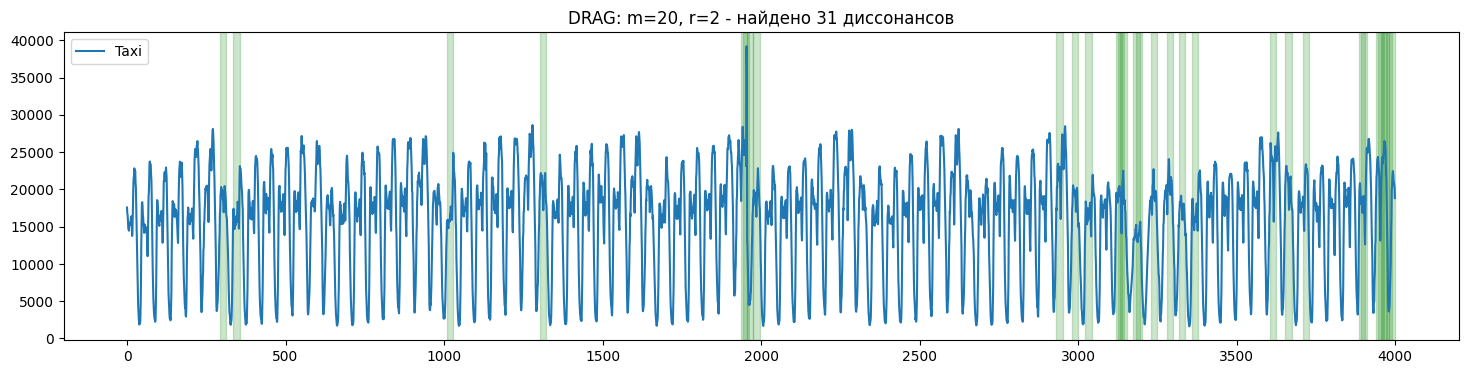

\Параметры: m=20, r=3


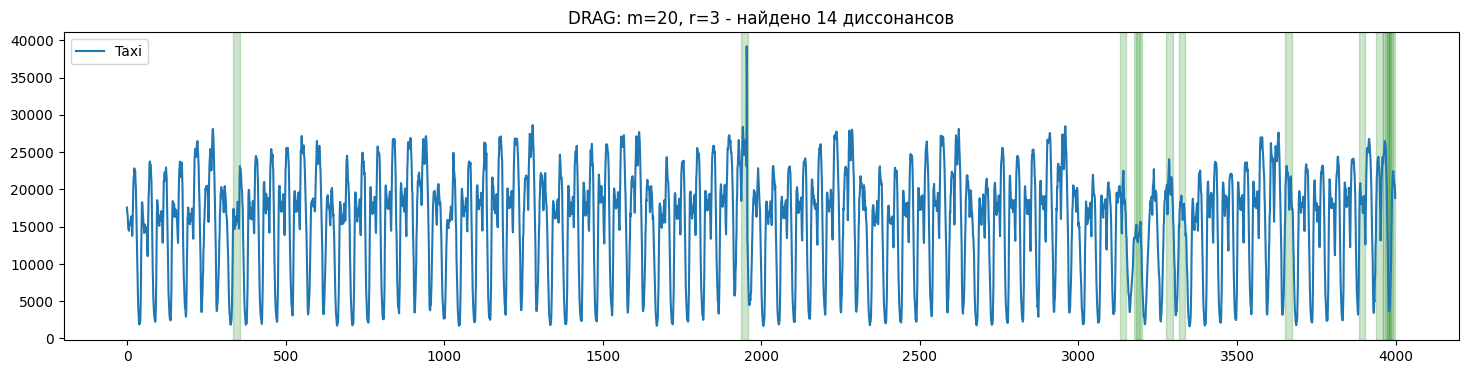

\Параметры: m=20, r=4


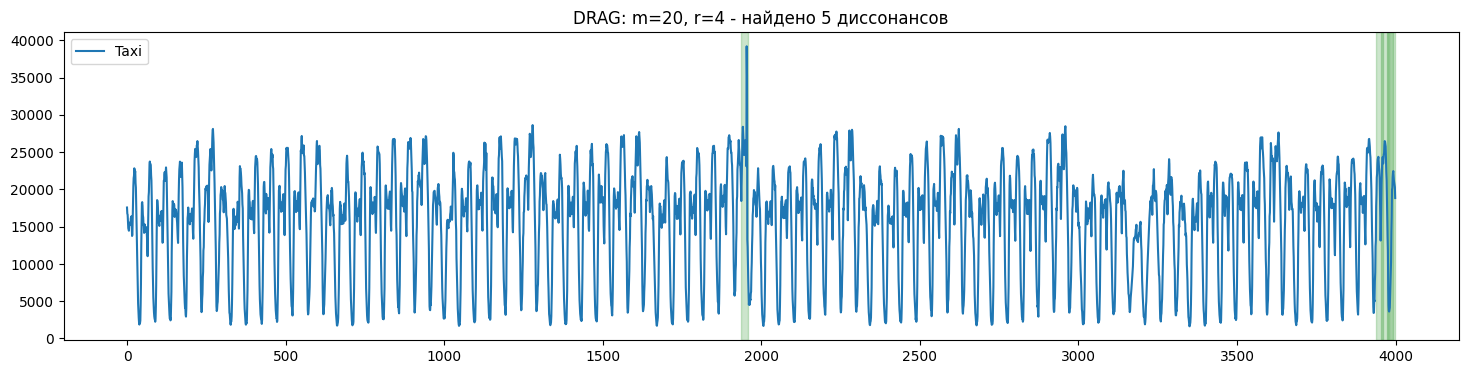

\Параметры: m=20, r=5


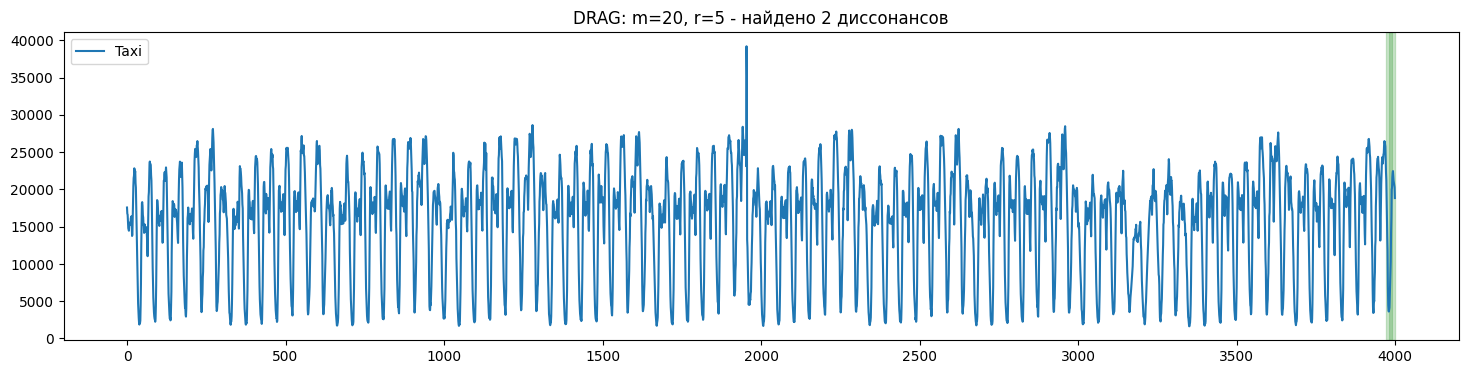

\Параметры: m=30, r=1


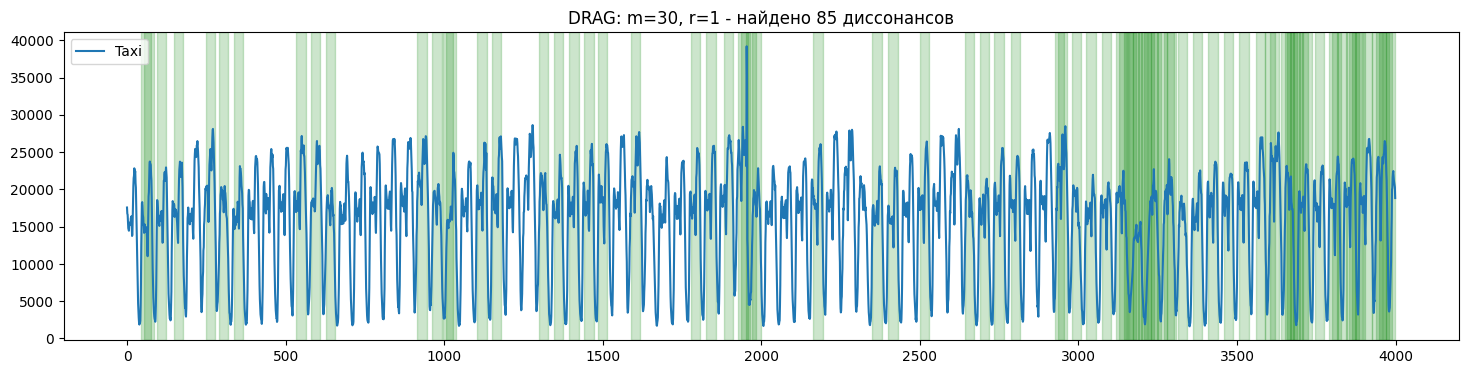

\Параметры: m=30, r=2


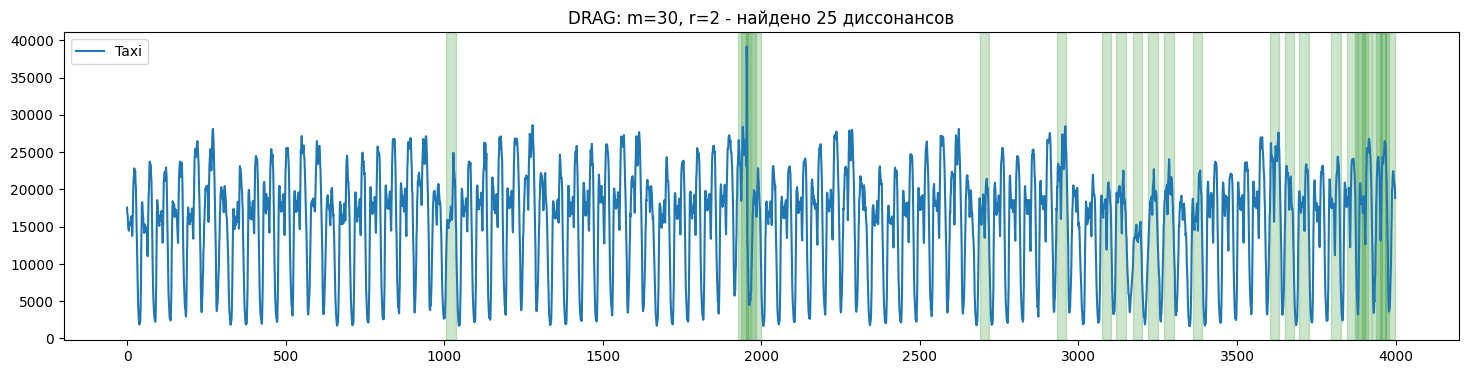

\Параметры: m=30, r=3


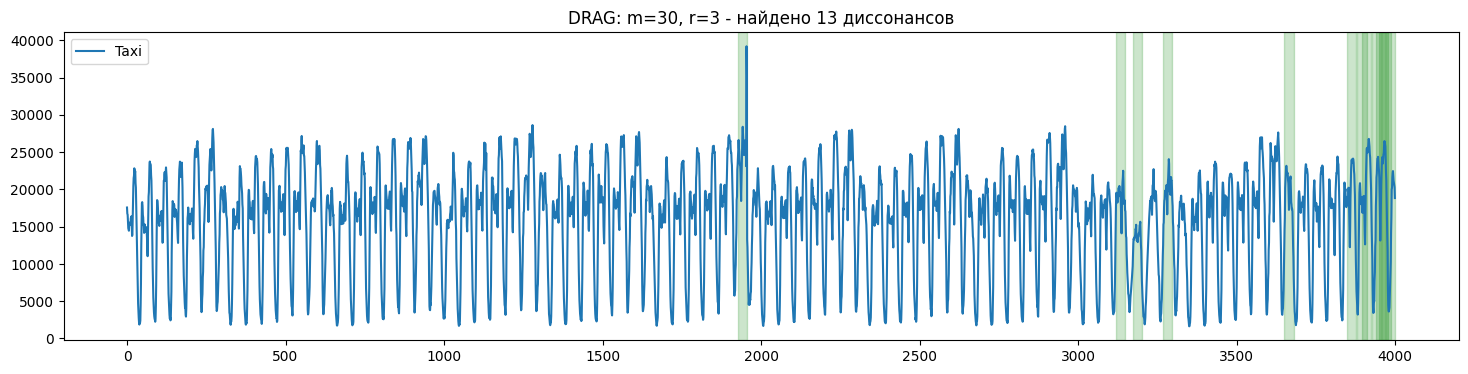

\Параметры: m=30, r=4


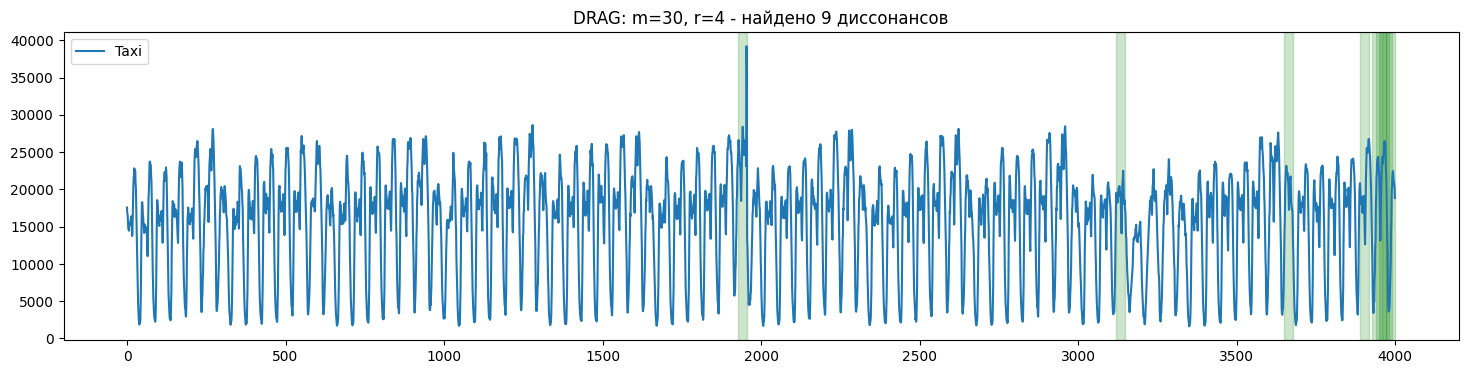

\Параметры: m=30, r=5


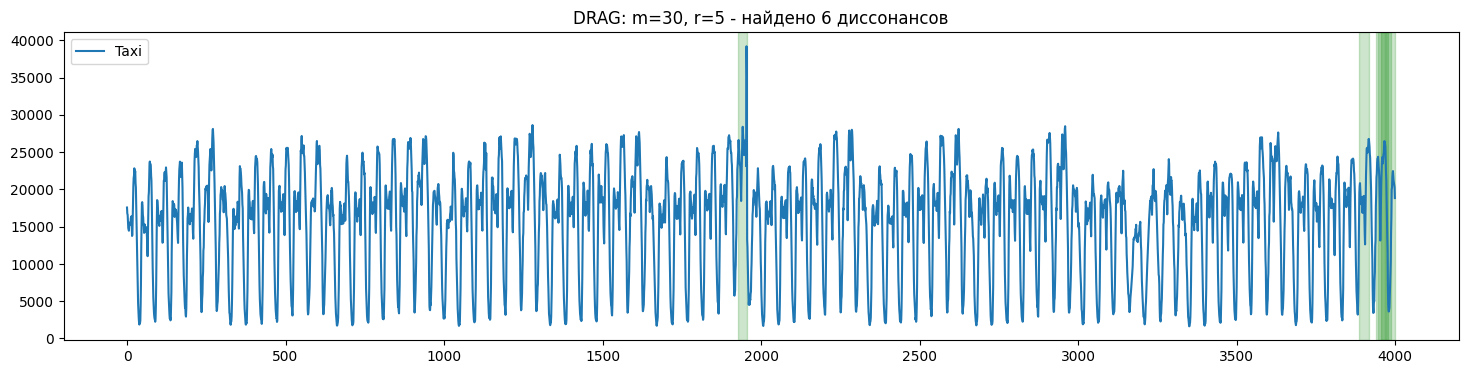

\Параметры: m=40, r=1


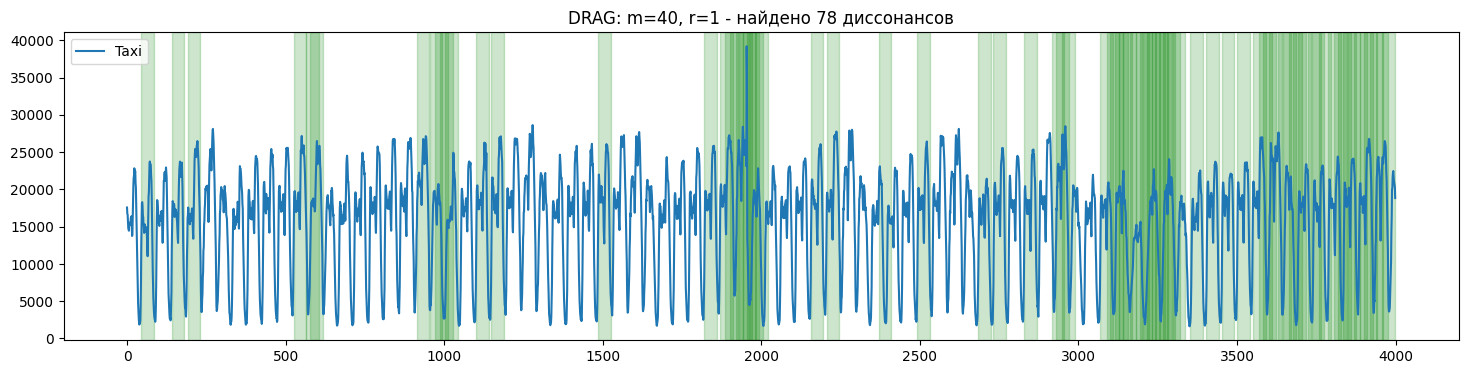

\Параметры: m=40, r=2


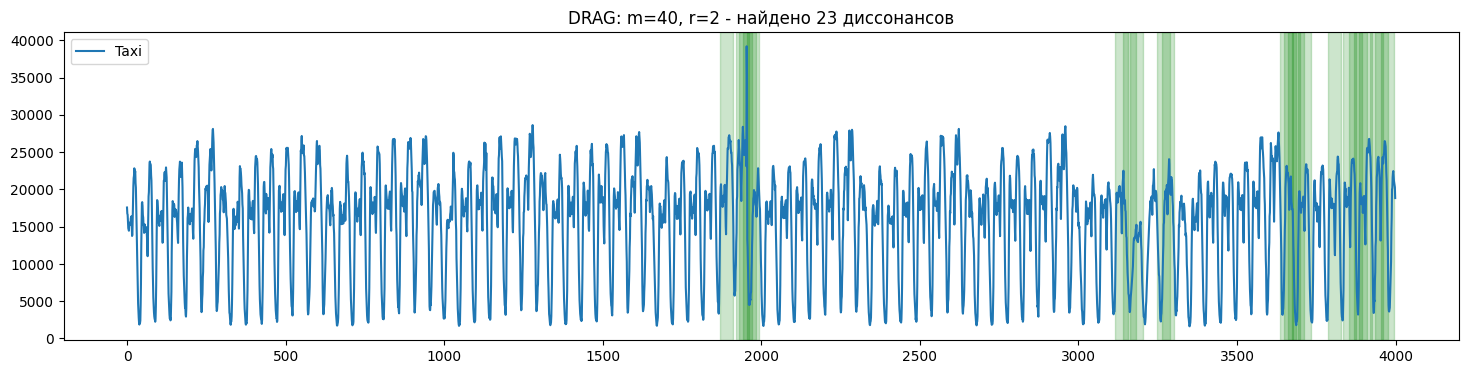

\Параметры: m=40, r=3


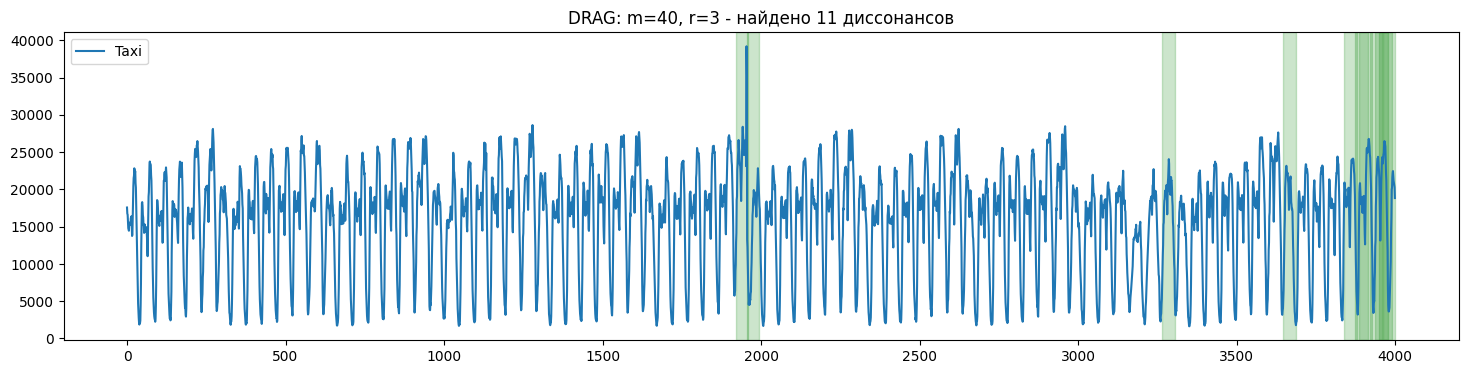

\Параметры: m=40, r=4


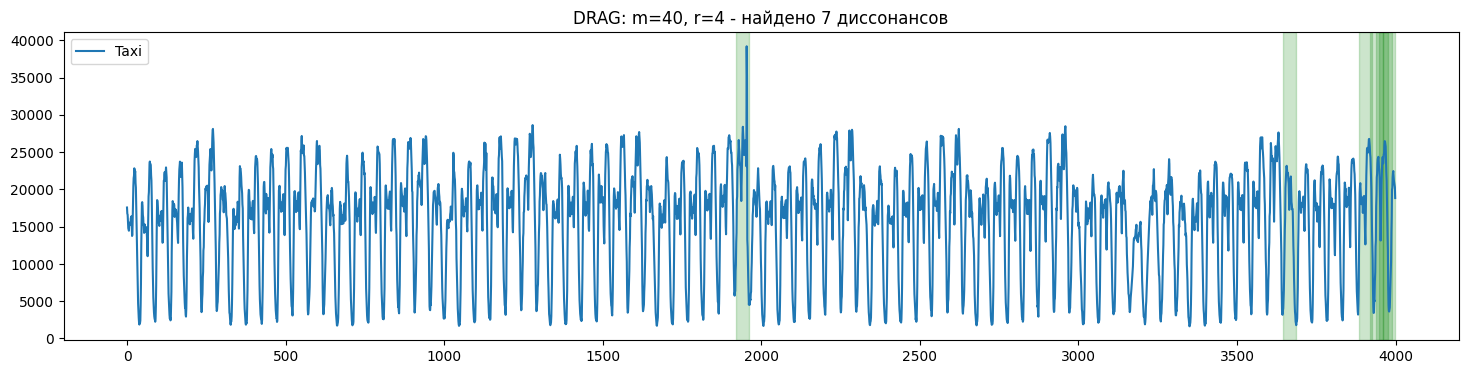

\Параметры: m=40, r=5


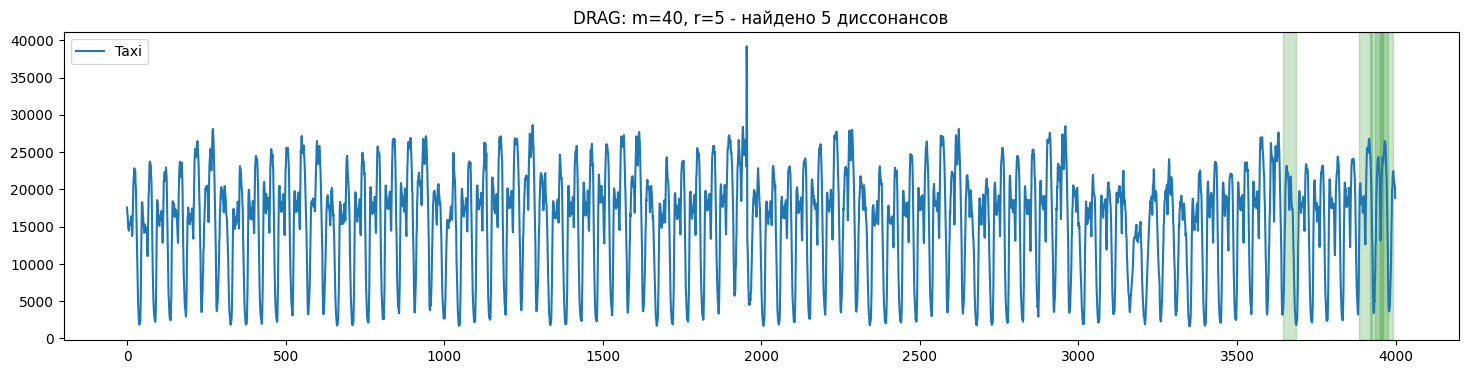

\Параметры: m=50, r=1


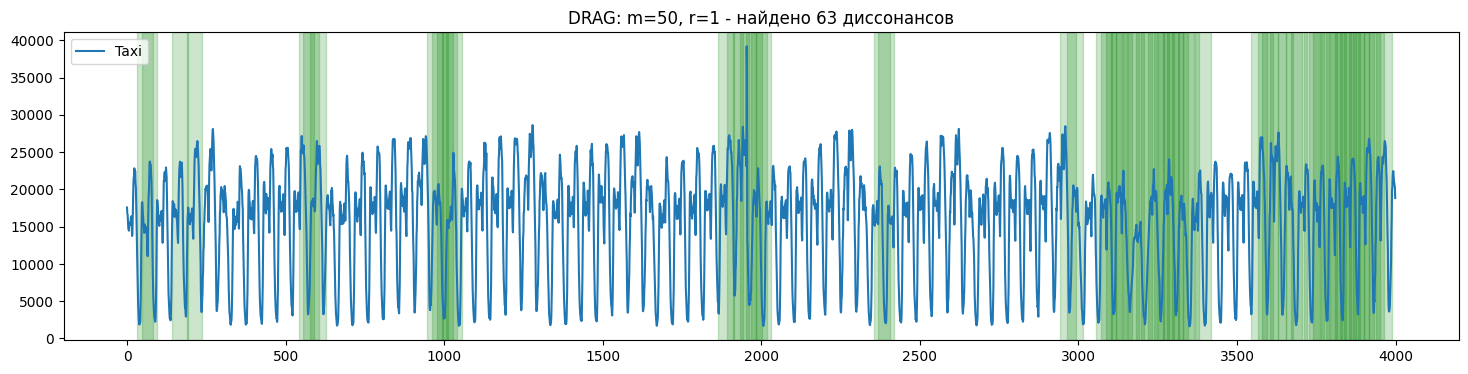

\Параметры: m=50, r=2


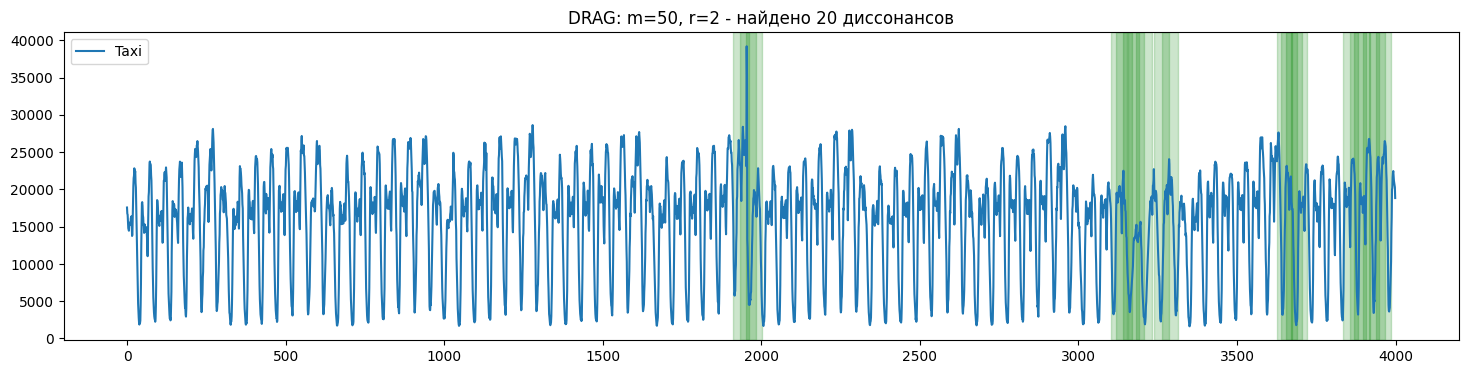

\Параметры: m=50, r=3


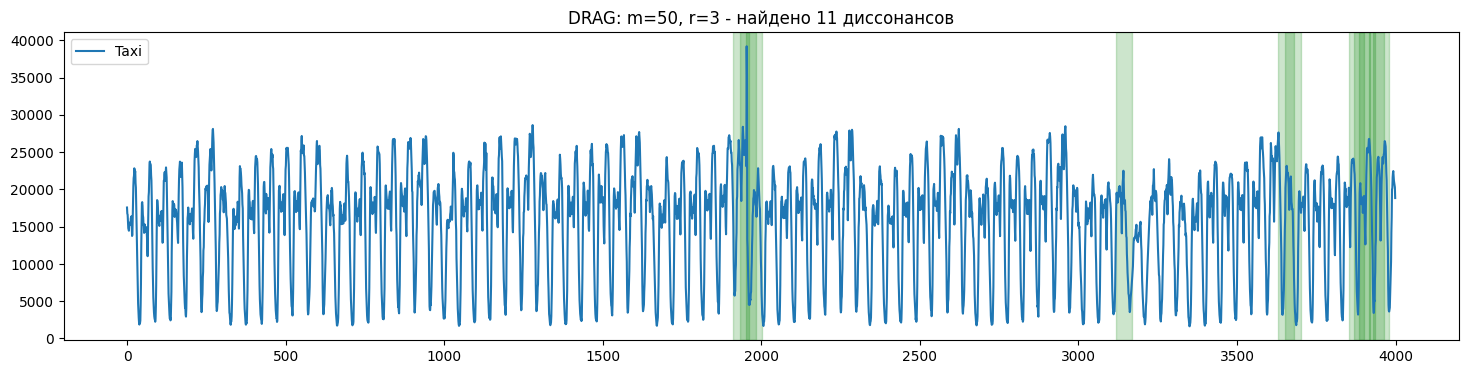

\Параметры: m=50, r=4


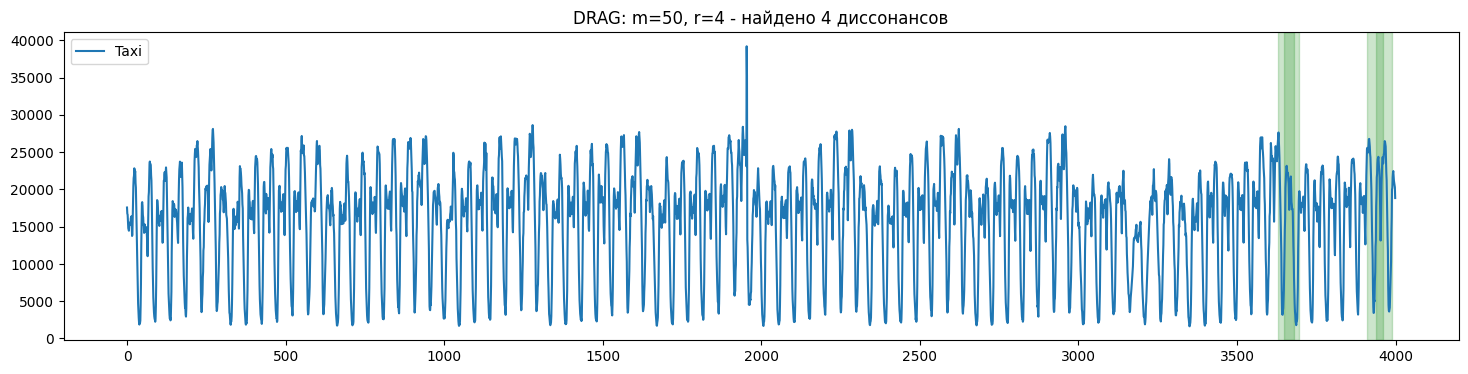

\Параметры: m=50, r=5


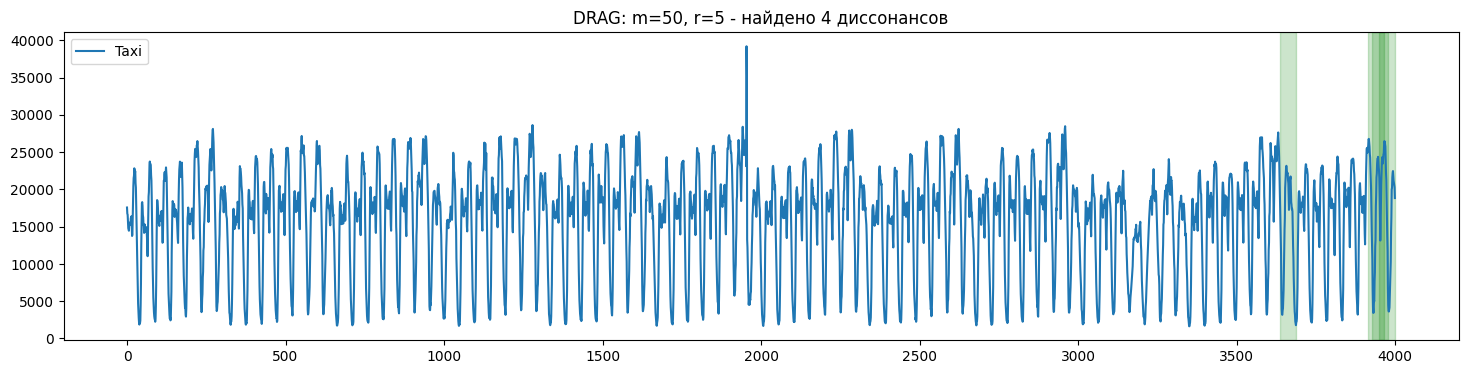

\Параметры: m=60, r=1


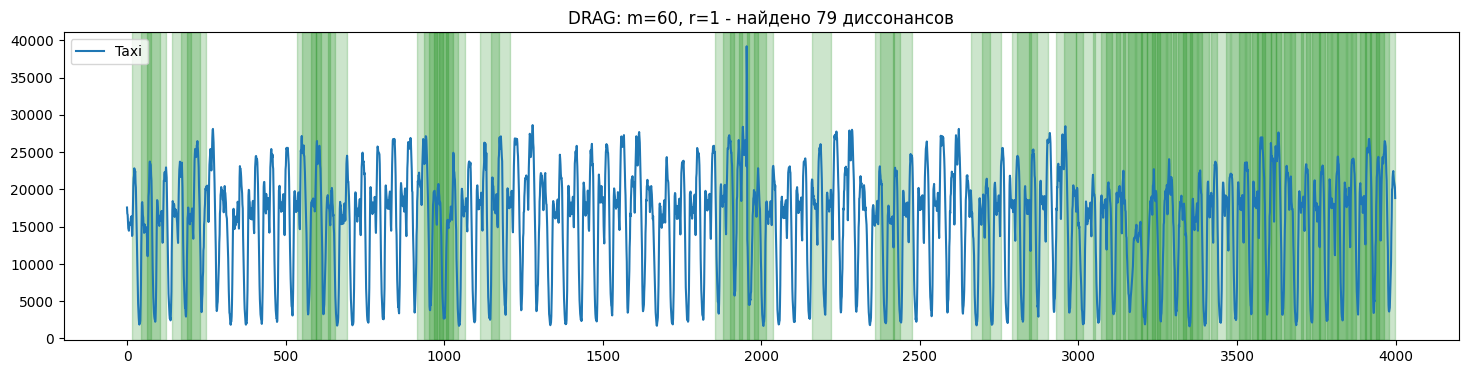

\Параметры: m=60, r=2


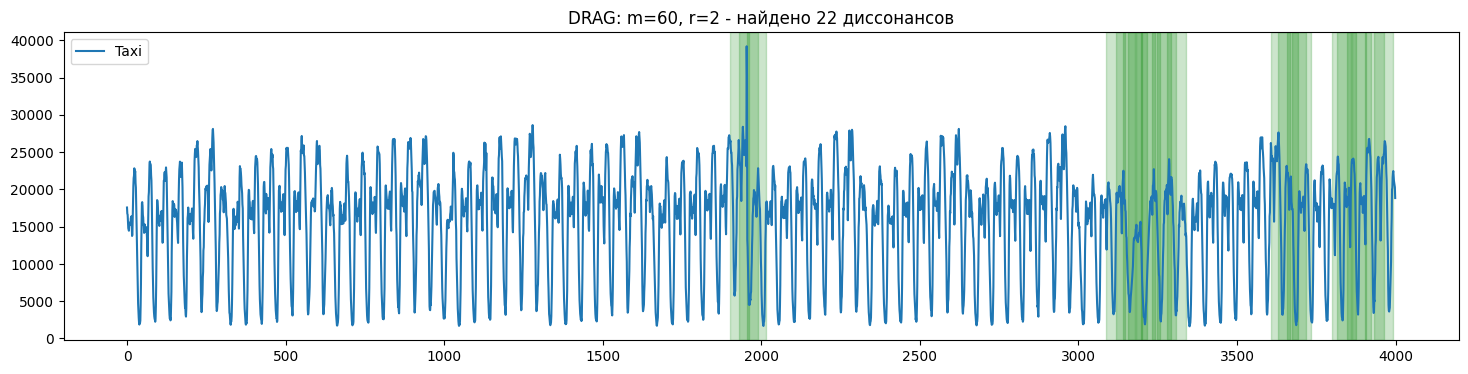

\Параметры: m=60, r=3


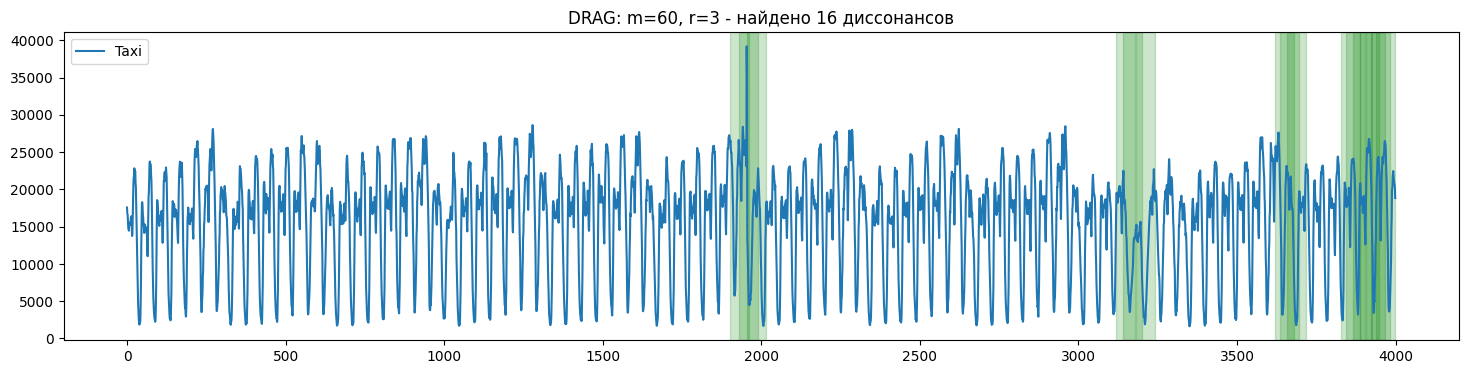

\Параметры: m=60, r=4


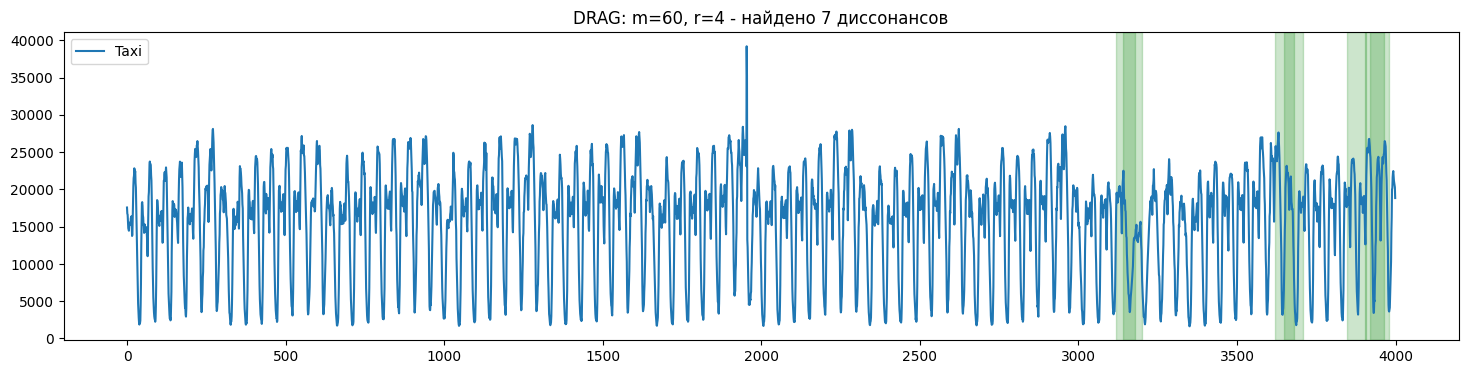

\Параметры: m=60, r=5


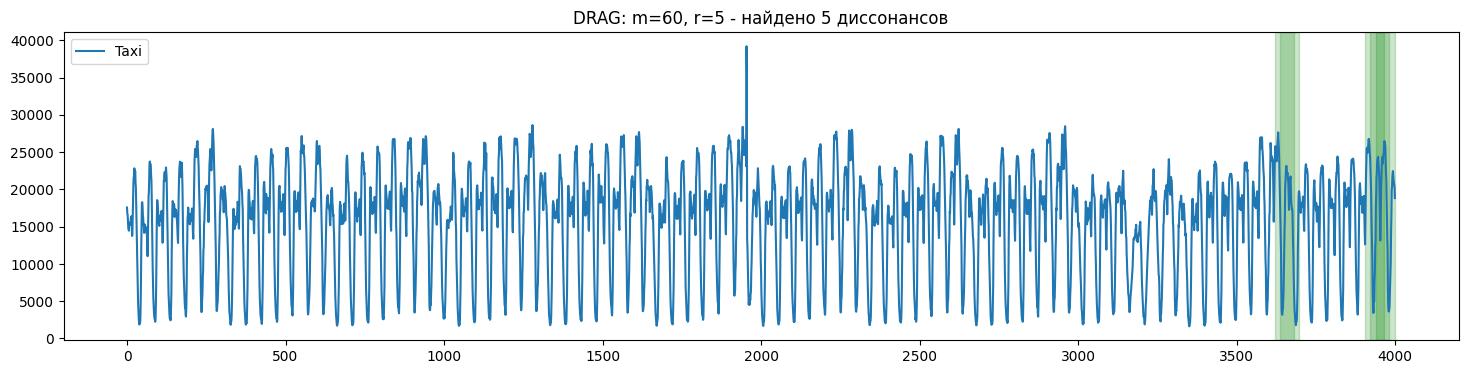

\Параметры: m=70, r=1


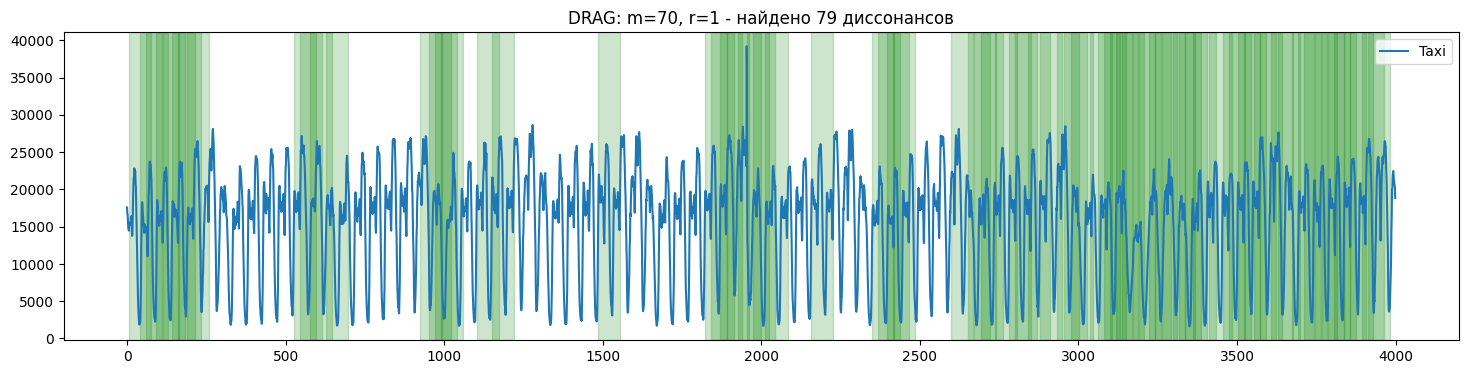

\Параметры: m=70, r=2


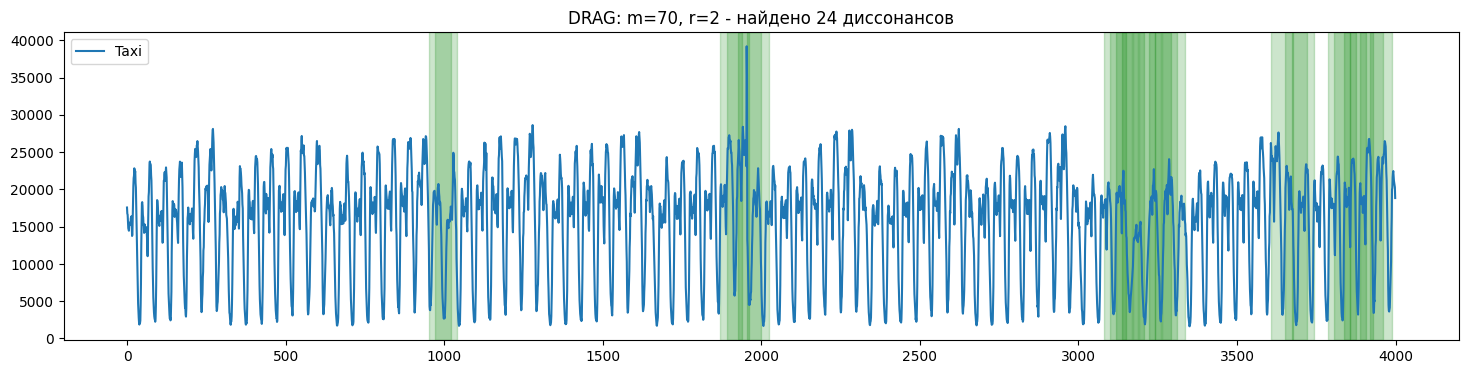

\Параметры: m=70, r=3


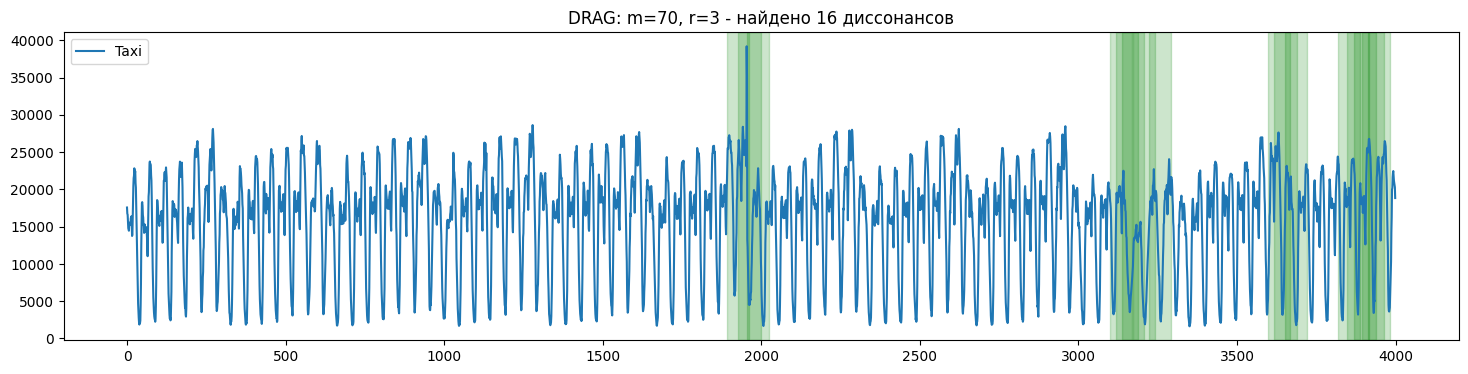

\Параметры: m=70, r=4


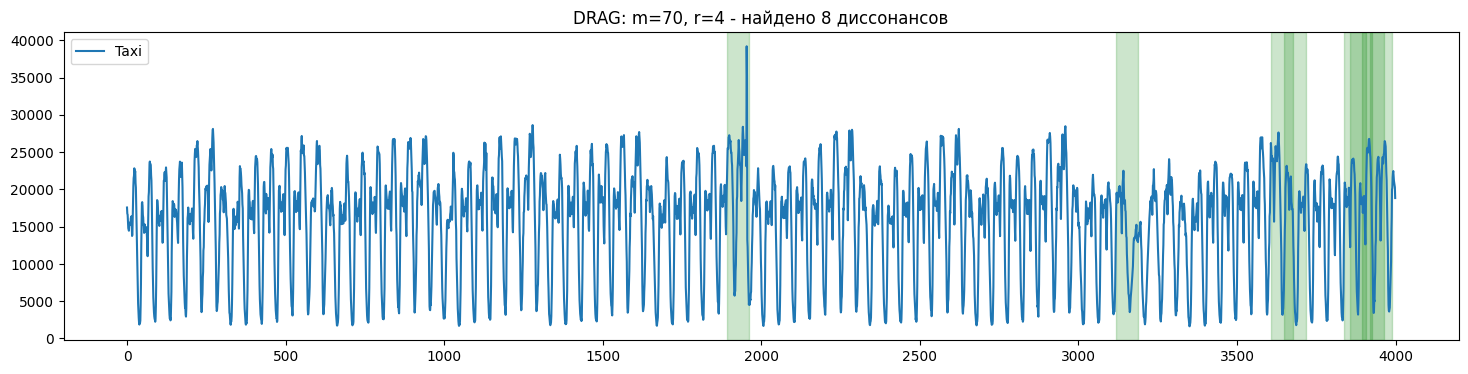

\Параметры: m=70, r=5


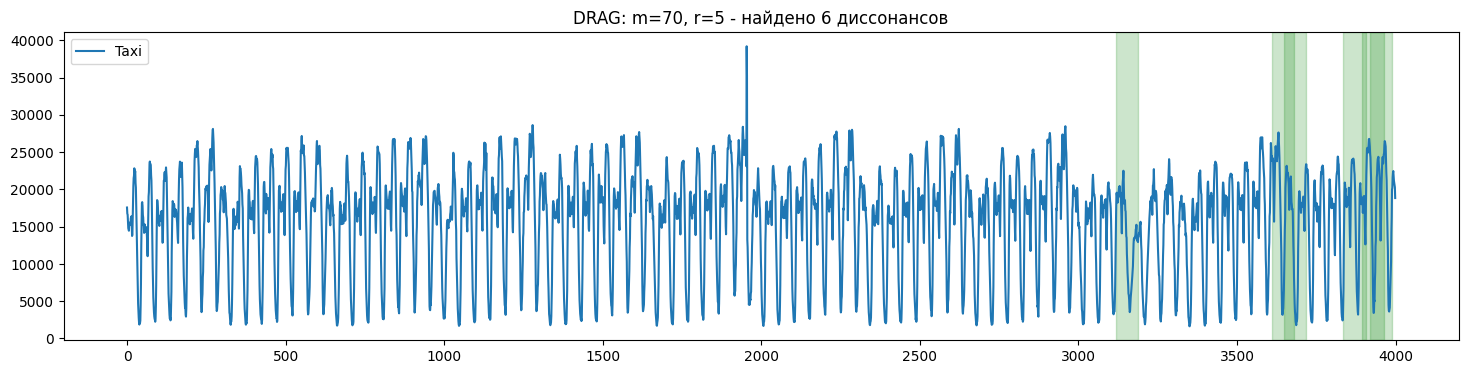

\Параметры: m=80, r=1


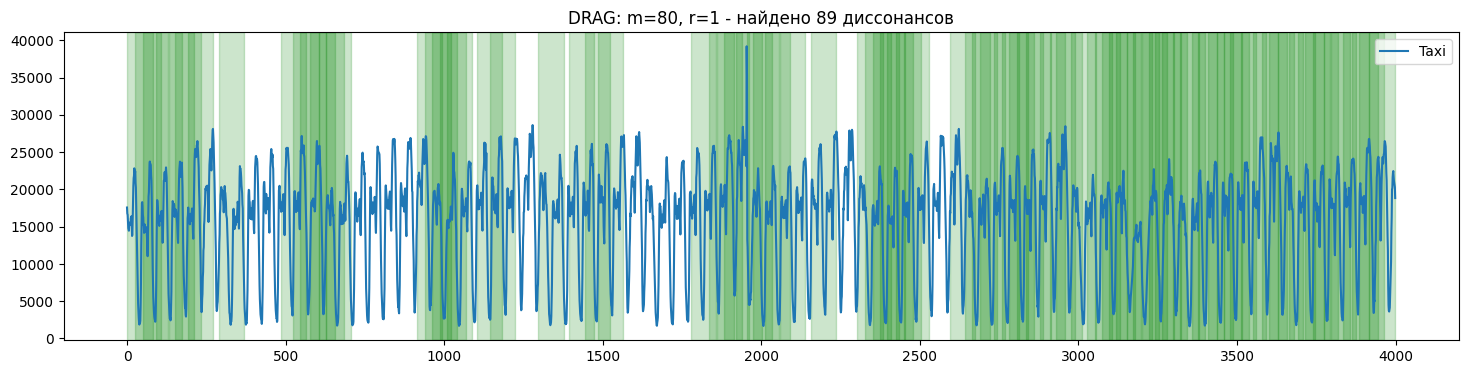

\Параметры: m=80, r=2


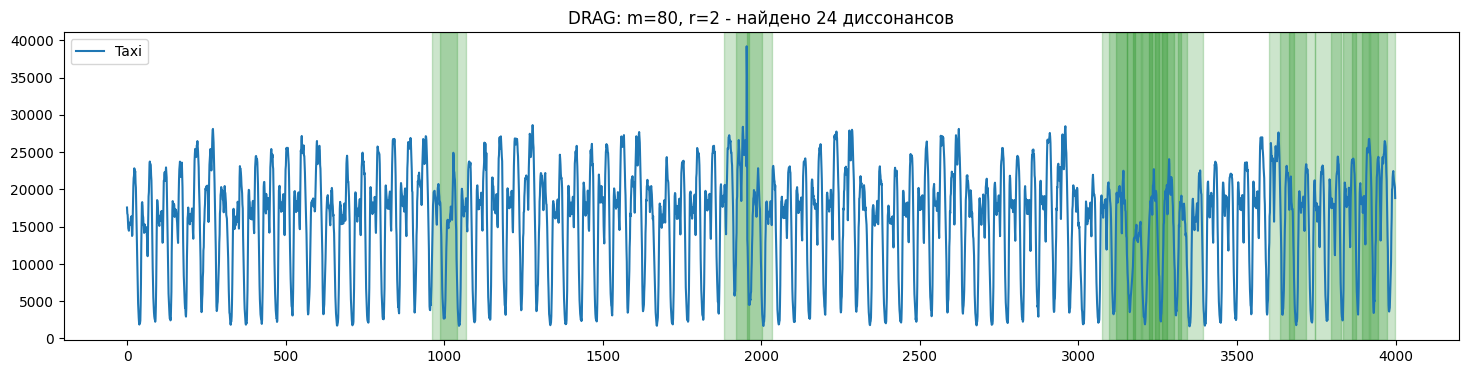

\Параметры: m=80, r=3


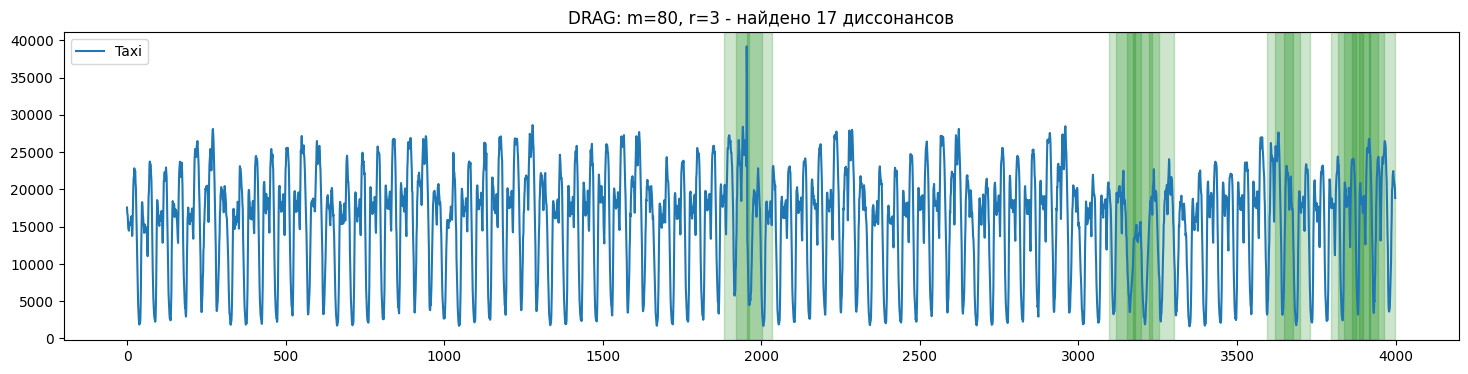

\Параметры: m=80, r=4


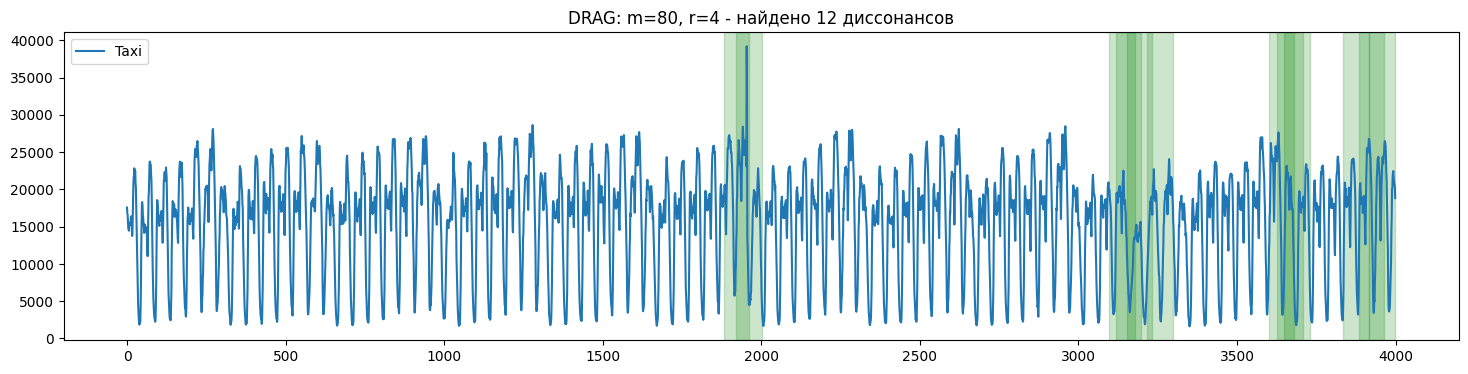

\Параметры: m=80, r=5


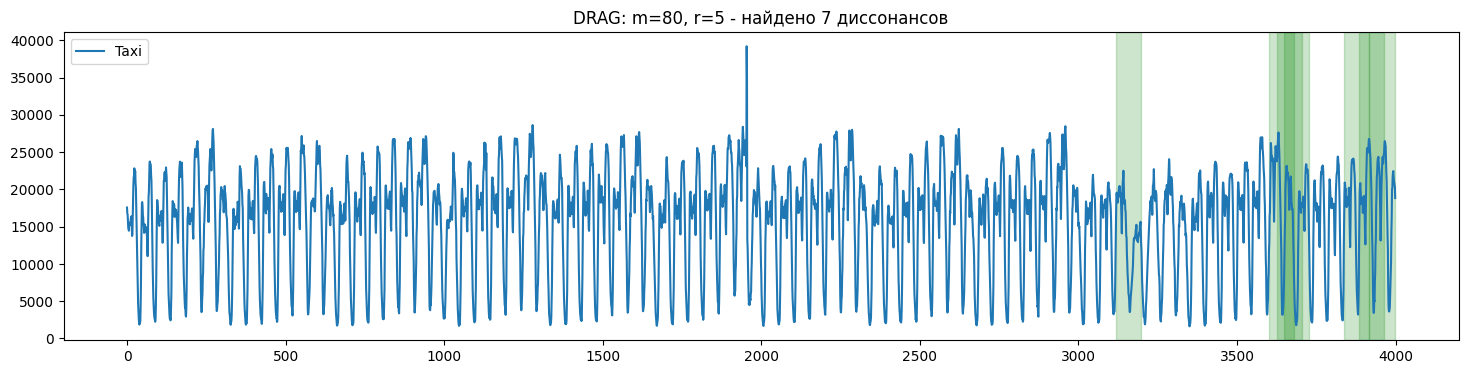

In [94]:
# Длины окна m
m_values = [20, 30, 40, 50, 60, 70, 80]

# Пороги r
r_values = [1, 2, 3, 4, 5]

results = []

for m in m_values:
    for r in r_values:
        print(f"\Параметры: m={m}, r={r}")
        n_discords = run_drag_visual(nyc_taxi, m, r)
        results.append((m, r, n_discords))

Вывод:
Значение r - порог для диссонансов/
1) задаёт минимальное расстояние между подпоследовательностью и её ближайшими соседями.

2) Чем меньше r - алгоритм считает почти всё необычным  (много диссонансов, включая шум)

3) Чем больше r - алгоритм считает только сильно отличающиеся подпоследовательности (меньше диссонансов, только явные аномалии)

r контролирует строгость определения аномалии.

Значение m - длина окна (подпоследовательности)
1) m определяет размер сегмента временного ряда, который мы сравниваем с соседями.

2) Малое m - короткие подпоследовательности, что проявляется в чувствительности к локальному шуму, а значит может создать много ложных диссонансов.

3) Большое m - длинные подпоследовательности, учитываются только более протяжённые изменения, мелкие аномалии могут быть пропущены.

Вывод: m контролирует масштаб анализа: маленькие окна ловят мелкие изменения, большие окна - крупные аномалии.

Оптимальная комбинация для выявления смены активности:  
m = 80 r = 4 (12 диссонансов)  
m = 50 r = 3 (11 диссонансов)  
m = 30 r = 3 (13 диссонансов)


#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse/blob/main/practice/03%20Discords/pics/first_part.png?raw=1)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов.

In [ ]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса,
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10


In [ ]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [ ]:
maxL

55

In [ ]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых.
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы.

![merlin-part-first](https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse/blob/main/practice/03%20Discords/pics/second_part.png?raw=1)


In [ ]:
# INSERT YOUR CODE

Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов.


In [ ]:
# INSERT YOUR CODE